In [37]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('./data/train.csv')

In [39]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [40]:
df.shape

(1460, 81)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [42]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [43]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [44]:
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x : x.fillna(x.median()))

In [45]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [46]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [47]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: >

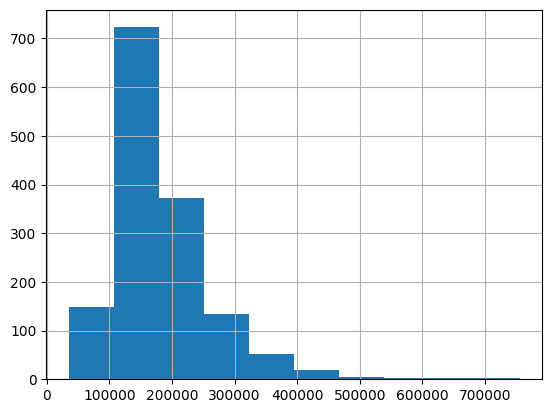

In [48]:
df['SalePrice'].hist()

<Axes: >

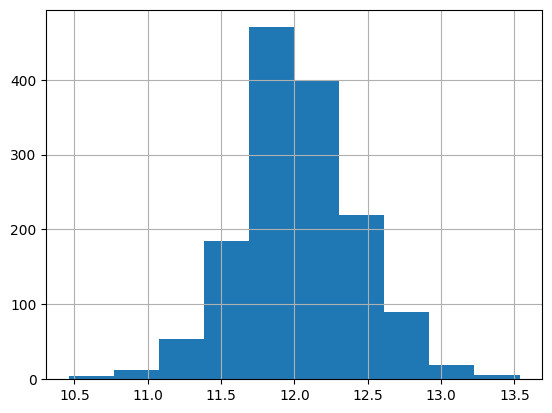

In [49]:
np.log(df['SalePrice']).hist()

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [51]:
num_cols = df.select_dtypes(include=['int64', 'float64'])
cat_cols = df.select_dtypes(include=['str'])


In [52]:
num_cols.value_counts()

Id    MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  YearRemodAdd  MasVnrArea  BsmtFinSF1  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd  Fireplaces  GarageYrBlt  GarageCars  GarageArea  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea  MiscVal  MoSold  YrSold  SalePrice
1     60          65.0         8450     7            5            2003       2003          196.0       706         0           150        856          856       854       0             1710       1             0             2         1         3             1             8             0           2003.0       2           548         0           61           0              0          0            0         0        2       2008    208500       1
2     20          80.0         9600     6            8            1976       1976          0.0         978 

In [53]:
print("Number of numerical columns:", num_cols.shape[1])
print("Number of categorical columns:", cat_cols.shape[1])

Number of numerical columns: 38
Number of categorical columns: 43


In [54]:
skewness = num_cols.skew().sort_values(ascending=False)
high_skew = skewness[skewness > 1]
low_skew = skewness[skewness < 1]

In [55]:
onehot_cols = []
high_card_cols = []

for col in cat_cols:
    if df[col].nunique() <= 10:
        onehot_cols.append(col)
    else:
        high_card_cols.append(col)

In [56]:
print(onehot_cols)
print(high_card_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['Neighborhood', 'Exterior1st', 'Exterior2nd']


In [57]:
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

In [58]:
for col in high_card_cols:
    freq = df[col].value_counts() / len(df)
    df[col] = df[col].map(freq)

In [59]:
bool_cols = df.select_dtypes(include='bool').columns

for col in bool_cols:
    df[col] = df[col].astype(int)

In [60]:
skewness = df.skew().sort_values(ascending=False)
high_skew = skewness[abs(skewness) > 1]
for col in high_skew.index:
    if col != 'SalePrice':  
        df[col] = np.log1p(df[col])

In [61]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [62]:
corr = df.corr()['SalePrice'].abs().sort_values(ascending=False)

In [63]:
useful_features = corr[corr > 0.1].index
X = X[useful_features.drop('SalePrice')]

In [64]:
corr = df.corr()['SalePrice'].abs().sort_values(ascending=False)

useful_features = corr[corr > 0.05].index
X = df[useful_features.drop('SalePrice')]

In [65]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,3.818794,4.216797,9.110966,0.068343,6.099315,5.575342,1971.267808,1984.865753,0.199354,...,0.002374,0.002374,0.057921,0.001424,0.601519,0.001899,0.005697,0.009495,0.568760,0.059345
std,421.610009,0.688354,0.323806,0.517369,0.043728,1.382997,1.112799,30.202904,20.645407,0.120145,...,0.040508,0.040508,0.191880,0.031399,0.234849,0.036244,0.062603,0.080597,0.266073,0.194007
min,1.000000,3.044522,3.091042,7.170888,0.001370,1.000000,1.000000,1872.000000,1950.000000,0.000685,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,365.750000,3.044522,4.110874,8.929898,0.034932,5.000000,5.000000,1954.000000,1967.000000,0.141096,...,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000,0.693147,0.000000
50%,730.500000,3.931826,4.262680,9.156887,0.054110,6.000000,5.000000,1973.000000,1994.000000,0.152055,...,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000,0.693147,0.000000
75%,1095.250000,4.262680,4.394449,9.358976,0.102740,7.000000,6.000000,2000.000000,2004.000000,0.352740,...,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000,0.693147,0.000000
max,1460.000000,5.252273,5.749393,12.279537,0.154110,10.000000,9.000000,2010.000000,2010.000000,0.352740,...,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147


In [67]:
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [68]:
y = np.log1p(df['SalePrice'])

In [69]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [70]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "RF": RandomForestRegressor(random_state=42),
    "XGB": xgb.XGBRFRegressor(random_state=42)
}

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def evaluate_model(model, X, y):
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),  # handle NaNs
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    return -np.mean(scores)

In [ ]:
X_train = X_train.astype(float)

In [84]:
results = []

for name, model in models.items():
        rmse = evaluate_model(model, X_train, y_train)
        
        results.append({
            "model": name,
            "rmse": rmse
        })

pd.DataFrame(results).sort_values("rmse")   

,model,rmse
1,Ridge,0.145677
0,Linear,0.149532
2,RF,0.153652
3,XGB,0.162478


In [87]:
def add_features(df):
    df = df.copy()
    
    # Total Square Footage
    required_sf = ["1stFlrSF", "2ndFlrSF", "TotalBsmtSF"]
    if all(col in df.columns for col in required_sf):
        df["TotalSF"] = df["1stFlrSF"] + df["2ndFlrSF"] + df["TotalBsmtSF"]
    
    # House Age
    if "YrSold" in df.columns and "YearBuilt" in df.columns:
        df["Age"] = df["YrSold"] - df["YearBuilt"]
    
    return df

In [88]:
X_train = add_features(X_train)
X_test = add_features(X_test)

In [89]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

model = xgb.XGBRegressor(random_state=42)

search = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=10,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

In [91]:
from sklearn.metrics import mean_squared_error

y_pred = best_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred, squared=False)

print("Final RMSE:", rmse)

TypeError: got an unexpected keyword argument 'squared'